[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/josterri/predicting-the-next-words-notebooks/blob/main/ch05_workbook.ipynb)

# Gradients through time

Backpropagation through time multiplies a learning signal by a factor at
every step it travels back, so the signal shrinks or grows exponentially with
the distance. An LSTM sends the signal back along its cell state, where, to
first order, the factor at each step is a forget gate the network learns.

In [1]:
#@title Setup: run this cell first
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

STEPS = 50
H = 32
VANILLA = 0.8
GROW = 1.2
STYLES = ["-o", "--s", ":^", "-.D"]
rng = np.random.default_rng(0)
#% Every random draw happens here, once and in this order, so rerunning a
#% step or the exercise never changes the numbers its solution states.
Q = np.linalg.qr(rng.normal(size=(H, H)))[0]
INPUTS = rng.normal(0, 0.1, size=(STEPS, H))
DIRECTIONS = rng.normal(size=(STEPS + 1, H))
DIRECTIONS /= np.linalg.norm(DIRECTIONS, axis=1, keepdims=True)
#% A setting outside its range ends in a sentence naming the range the check
#% enforces. Inside it every chart draws and every printed value is above 0:
#% a factor's 50th power stays within 1e-100 to 1e100, and at σ_max = 3
#% the smallest tanh derivative is still above 0 in a 64-bit float.
RANGES = {
    "FACTOR": (0.01, 100, "A factor is the size of one step's Jacobian."),
    "FORGET": (0.01, 1, "A forget gate is a sigmoid's output, at most 1."),
    "THRESHOLD": (0.001, 1e6, "A threshold is a length."),
    "SIGMA_MAX": (0.1, 3, "σ_max is the largest singular value of W_hh."),
}


def ok(name, value):
    """True when a setting is a number in its range; otherwise a sentence naming the range."""
    low, high, what = RANGES[name]
    if isinstance(value, (int, float)) and low <= value <= high:
        return True
    display(Markdown(f"`{name} = {value!r}` stops the cell: `{name}` takes a number from {fmt(low)} to {fmt(high)}. {what}"))
    return False


def left(factor):
    """The size of a signal multiplied by factor at each step, from the loss (step 0) to step STEPS."""
    return factor ** np.arange(STEPS + 1.0)


def clip_factor(g, tau):
    """The one factor that rescales the whole gradient g to length tau when it is longer (Pascanu et al. 2013, Algorithm 1)."""
    return min(1.0, tau / np.linalg.norm(g))


def clipping(tau):
    """Each step's contribution to one gradient, before and after clipping that gradient, for GROW and VANILLA;
    and each gradient's norm and clipping factor. Step k's contribution has length factor ** k and its own direction."""
    series, totals = {}, {}
    for f in (GROW, VANILLA):
        parts = f ** np.arange(STEPS + 1.0)[:, None] * DIRECTIONS
        g = parts.sum(axis=0)
        totals[f] = np.linalg.norm(g), clip_factor(g, tau)
        series[f"factor {f}, before clipping"] = np.linalg.norm(parts, axis=1)
        series[f"factor {f}, after clipping"] = np.linalg.norm(parts * totals[f][1], axis=1)
    return series, totals


def jacobian_norms(sigma):
    """Spectral norm of ∂h_T/∂h_k = J_T ⋯ J_(k+1) for T − k = 0 to STEPS, with W_hh = sigma · Q, and the mean 1 − h²."""
    W, h, states = sigma * Q, np.zeros(H), []
    for u in INPUTS:
        h = np.tanh(W @ h + u)
        states.append(h)
    P, norms = np.eye(H), [1.0]
    for h in reversed(states):
        P = P @ (np.diag(1 - h ** 2) @ W)
        norms.append(np.linalg.norm(P, 2))
    return np.array(norms), np.mean([1 - h ** 2 for h in states])


def fmt(x):
    """A value to three significant figures, with thousands commas between 1,000 and a billion."""
    return f"{x:,.0f}" if 1e3 <= abs(x) < 1e9 else f"{x:.3g}"


def line(series, ylabel, marks=(), ref=None):
    """One line per series against the steps back, on a log axis, with each value at the marked steps."""
    fig, ax = plt.subplots(figsize=(6, 3.5))
    for i, (label, y) in enumerate(series.items()):
        #% Markers start two steps apart per series, so a line that coincides with another still shows.
        ax.plot(y, STYLES[i], markevery=(2 * i, 10), label=label)
    if ref:
        ax.axhline(ref[0], color="gray", lw=0.8, label=ref[1])
    #% The y-axis spans the data with a twentieth of its decades either side, a factor of 2 at least, and two
    #% decades in all at least, so a nearly flat line gets decade ticks and no labels of the form 1.1 × 10⁰.
    lo, hi = min(min(y) for y in series.values()), max(max(y) for y in series.values())
    pad = max(2.0, (hi / lo) ** 0.05, np.sqrt(100 * lo / hi))
    ax.set_yscale("log")
    ax.set(xlabel="steps back from the loss", ylabel=ylabel, xlim=(0, STEPS + 9), ylim=(lo / pad, hi * pad))
    ax.legend(fontsize=8, ncol=2, loc="lower left", bbox_to_anchor=(0, 1.01), frameon=False)
    for k in marks:
        #% Each label sits 5 points above its value, pushed up to stay 10 points above the label below it.
        floor = -np.inf
        for v in sorted(y[k] for y in series.values()):
            at = ax.transData.transform((k, v))[1] * 72 / fig.dpi
            floor = max(at + 5, floor + 10)
            ax.annotate(fmt(v), (k, v), xytext=(5, floor - at), textcoords="offset points", fontsize=8, va="center")
    plt.show()


display(Markdown(f"Every path runs {STEPS} steps back from the loss. The vanilla RNN has {H} hidden units and "
                 f"{STEPS} random inputs."))

Every path runs 50 steps back from the loss. The vanilla RNN has 32 hidden units and 50 random inputs.

## 1. A signal multiplied at every step

Run the cell: a learning signal travelling back from the loss is multiplied
by `FACTOR` at each of 50 steps; then set `FACTOR = 0.8` and run it again.
What fraction of the signal is left after 20 steps, and what fraction after 50?

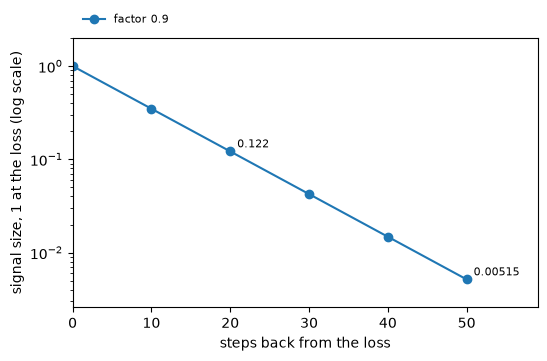

In [2]:
FACTOR = 0.9
if ok("FACTOR", FACTOR):
    line({f"factor {FACTOR:g}": left(FACTOR)}, "signal size, 1 at the loss (log scale)", marks=(20, STEPS))

### Solution

In [3]:
if ok("FACTOR", FACTOR):
    y = left(FACTOR)
    display(Markdown(f"At a factor of {FACTOR:g}, the signal is {fmt(y[20])} times its size at the loss after 20 steps "
                     f"and {fmt(y[STEPS])} times after {STEPS}. The {STEPS - 20} steps between them multiply it by "
                     f"{fmt(y[STEPS] / y[20])}, the factor to the power {STEPS - 20}."))

At a factor of 0.9, the signal is 0.122 times its size at the loss after 20 steps and 0.00515 times after 50. The 30 steps between them multiply it by 0.0424, the factor to the power 30.

## 2. The forget gate sets the rate along the cell state

Run the cell: along an LSTM's cell state the signal is multiplied by the
forget gate `FORGET` at each step, and along a vanilla RNN's hidden state by
a decay factor of 0.8; then set `FORGET` below 0.8 and run it again. The two
constants are the lecture's pair: the network learns its forget gate and can
hold it near 1, while the vanilla factor is set by W_hh and the derivative of
tanh. Which path keeps more of the signal after 50 steps, and how many times
more?

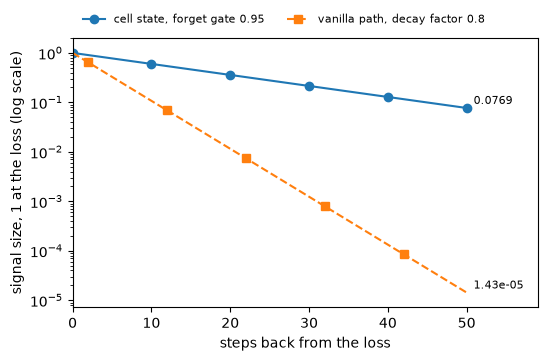

In [4]:
FORGET = 0.95
if ok("FORGET", FORGET):
    line({f"cell state, forget gate {FORGET:g}": left(FORGET), f"vanilla path, decay factor {VANILLA}": left(VANILLA)},
         "signal size, 1 at the loss (log scale)", marks=(STEPS,))

### Solution

In [5]:
if ok("FORGET", FORGET):
    c, v = left(FORGET)[STEPS], left(VANILLA)[STEPS]
    more = f"the cell state keeps {fmt(c / v)} times more" if c > v else f"the vanilla path keeps {fmt(v / c)} times more"
    display(Markdown(f"After {STEPS} steps the cell state keeps {fmt(c)} of the signal at a forget gate of {FORGET:g}, "
                     f"and the vanilla path {fmt(v)} at a decay factor of {VANILLA}: "
                     + ("the same share." if c == v else more + ".")
                     + (f" Below 1 the gate still shrinks the cell state, by {FORGET:g} at every step." if FORGET < 1 else "")))

After 50 steps the cell state keeps 0.0769 of the signal at a forget gate of 0.95, and the vanilla path 1.43e-05 at a decay factor of 0.8: the cell state keeps 5,391 times more. Below 1 the gate still shrinks the cell state, by 0.95 at every step.

## 3. Clipping rescales the whole gradient by one factor

Run the cell: one backward pass sums the contributions of every step back
into one gradient, and when its norm passes `THRESHOLD`, clipping multiplies
the whole gradient, every contribution with it, by one factor. The
contributions grow by 1.2 per step back in one backward pass and shrink by 0.8
in another. What does clipping do to each gradient, and to the ratio between
its farthest and nearest contributions?

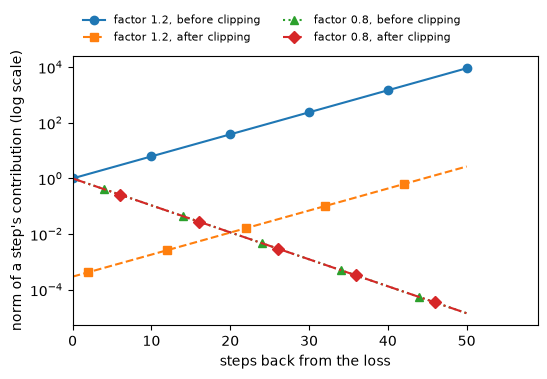

In [6]:
THRESHOLD = 5
if ok("THRESHOLD", THRESHOLD):
    series, totals = clipping(THRESHOLD)
    line(series, "norm of a step's contribution (log scale)")

### Solution

In [7]:
if ok("THRESHOLD", THRESHOLD):
    series, totals = clipping(THRESHOLD)
    act = lambda f: f"has norm {fmt(totals[f][0])}, " + ("below the threshold, and clipping leaves it unchanged"
          if totals[f][1] == 1 else f"and clipping multiplies it, every contribution with it, by {fmt(totals[f][1])}")
    ratio = {f: series[f"factor {f}, after clipping"][-1] / series[f"factor {f}, after clipping"][0] for f in totals}
    display(Markdown(f"At a threshold of {fmt(THRESHOLD)}, the factor-{GROW} gradient {act(GROW)}; the factor-{VANILLA} "
                     f"gradient {act(VANILLA)}. After clipping, the contribution from {STEPS} steps back is still "
                     f"{fmt(ratio[GROW])} times the one at the loss in the first and {fmt(ratio[VANILLA])} times in the "
                     f"second. At this threshold clipping " + ("bounds the explosion" if totals[GROW][1] < 1 else
                     "leaves the explosion as it was") + (" and leaves the fade as it was." if totals[VANILLA][1] == 1 else
                     ", and it multiplies the faded gradient by its own factor, which shrinks it further.")))

At a threshold of 5, the factor-1.2 gradient has norm 16,947, and clipping multiplies it, every contribution with it, by 0.000295; the factor-0.8 gradient has norm 1.74, below the threshold, and clipping leaves it unchanged. After clipping, the contribution from 50 steps back is still 9,100 times the one at the loss in the first and 1.43e-05 times in the second. At this threshold clipping bounds the explosion and leaves the fade as it was.

## Appendix. The Jacobian product and the cell path

A vanilla RNN starts at h_0 = 0 and updates its hidden state by

h_t = tanh(W_hh h_(t−1) + W_xh x_t + b_h),

so one step back multiplies the gradient by the Jacobian
J_t = diag(1 − h_t²) W_hh, and T − k steps back by the product

∂h_T/∂h_k = J_T J_(T−1) ⋯ J_(k+1),

with the latest step on the left. Every entry of diag(1 − h_t²) lies between
0 and 1, so in the spectral norm ‖·‖, a matrix's largest singular value,
‖∂h_T/∂h_k‖ ≤ σ_max^(T−k), where σ_max is the largest singular value of W_hh.
A fixed factor per step is this bound with σ_max equal to the factor, and the
tanh derivatives pull a real RNN's product below it. An LSTM updates its cell state by addition,
c_t = f_t ⊙ c_(t−1) + i_t ⊙ c̃_t, and to first order

∂c_T/∂c_k ≈ diag(f_(k+1) ⊙ … ⊙ f_T),

the product of the forget gates. With W_hh = σ_max · Q for a random orthogonal
Q, every singular value of W_hh equals σ_max, and so does its spectral radius.

A vanilla RNN of 32 hidden units runs at σ_max = 0.8 on an input term
W_xh x_t + b_h drawn with standard deviation 0.1, beside a cell state whose
forget gate holds at 0.95.

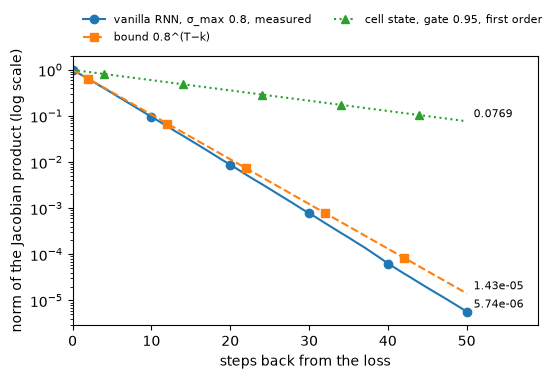

In [8]:
norms, _ = jacobian_norms(VANILLA)
line({f"vanilla RNN, σ_max {VANILLA}, measured": norms, f"bound {VANILLA}^(T−k)": left(VANILLA),
      "cell state, gate 0.95, first order": left(0.95)}, "norm of the Jacobian product (log scale)", marks=(STEPS,))

**Exercise.** Set `SIGMA_MAX` to 0.8, 1.0 and 1.2 in turn and rerun the cell
each time. At which of the three does the Jacobian product shrink over 50
steps, and how far below the bound σ_max^50 does it stay?

In [9]:
SIGMA_MAX = 1.0

if ok("SIGMA_MAX", SIGMA_MAX):
    n, mean = jacobian_norms(SIGMA_MAX)
    print(f"σ_max = {SIGMA_MAX:g}: the Jacobian product is {fmt(n[20])} after 20 steps and {fmt(n[STEPS])} after {STEPS}, "
          f"against a bound σ_max^{STEPS} of {fmt(SIGMA_MAX ** STEPS)}; the tanh derivatives 1 − h² average {mean:.3f}.")

σ_max = 1: the Jacobian product is 0.471 after 20 steps and 0.0744 after 50, against a bound σ_max^50 of 1; the tanh derivatives 1 − h² average 0.930.


### Solution

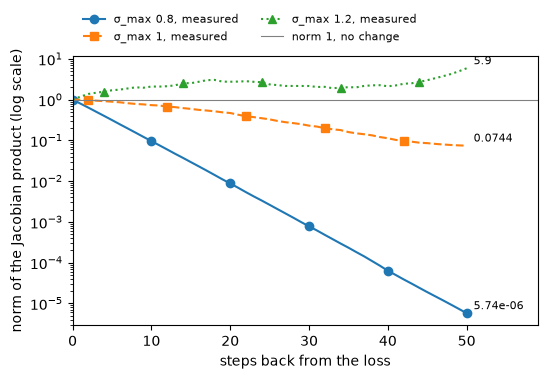

After 50 steps the product is 5.74e-06 at σ_max = 0.8, 2.49 times below its bound 1.43e-05; 0.0744 at σ_max = 1, 13.4 times below its bound 1; 5.9 at σ_max = 1.2, 1,542 times below its bound 9,100. It shrinks at σ_max = 0.8 and 1, and grows at 1.2. The gap to the bound widens as the mean tanh derivative 1 − h² falls, from 0.974 to 0.930 to 0.819: a larger σ_max drives the states into tanh's flat tails. In this network the product at σ_max = 1 is 0.0744, against 0.0769 for a cell state whose forget gate holds at 0.95, and on a grid of 0.01 the 50-step product first exceeds 1 at σ_max = 1.10. The network learns its forget gate, and this vanilla RNN reaches the gate's rate only with σ_max near 1, next to that onset of growth.

In [10]:
runs = {s: jacobian_norms(s) for s in (0.8, 1.0, 1.2)}
line({f"σ_max {s:g}, measured": n for s, (n, low) in runs.items()}, "norm of the Jacobian product (log scale)",
     marks=(STEPS,), ref=(1, "norm 1, no change"))
end = {s: n[STEPS] for s, (n, low) in runs.items()}
cell = 0.95 ** STEPS
onset = next((s for s in np.arange(1.0, 1.205, 0.01) if jacobian_norms(s)[0][STEPS] > 1), np.nan)
display(Markdown(
    f"After {STEPS} steps the product is "
    + "; ".join(f"{fmt(end[s])} at σ_max = {s:g}, {fmt(s ** STEPS / end[s])} times below its bound {fmt(s ** STEPS)}" for s in runs)
    + f". It shrinks at σ_max = {' and '.join(f'{s:g}' for s in runs if end[s] < 1)}, and grows at "
    f"{' and '.join(f'{s:g}' for s in runs if end[s] > 1) or 'none of the three'}. The gap to the bound widens as the "
    f"mean tanh derivative 1 − h² falls, from " + " to ".join(f"{runs[s][1]:.3f}" for s in runs) + ": a larger σ_max "
    f"drives the states into tanh's flat tails. In this network the product at σ_max = 1 is {fmt(end[1.0])}, against "
    f"{fmt(cell)} for a cell state whose forget gate holds at 0.95, and on a grid of 0.01 the {STEPS}-step product first "
    f"exceeds 1 at σ_max = {onset:.2f}. The network learns its forget gate, and this vanilla RNN reaches the gate's rate "
    f"only with σ_max near 1, next to that onset of growth."))